<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
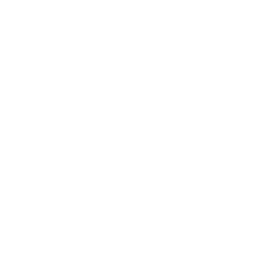
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Split-Plot-design til procesoptimering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Produktion / kvalitetsteknik &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Denne notebook analyserer et split-plot-forsøg for en
sprøjtestøbningsproces. Hel-parcel-faktoren er **maskine** (4 niveauer:
MACH_A-MACH_D), som er svær at ændre, og delparcel-faktoren er
**hastighedsindstilling** (5 niveauer: 60, 80, 100, 120, 140 RPM), som
er let at ændre. Der tages fem gentagne målinger ved hver maskine x
hastighed-kombination, hvilket giver 100 fejlrate-observationer.

`PROC MIXED` tilpasser den restringerede randomiseringsstruktur
korrekt ved at behandle **maskine som en tilfældig effekt**
(hel-parcel-fejlstratummet) og **hastighed som en fixed effect**
(delparcel-faktoren). Analysen estimerer de to variankomponenter,
tester hastighedseffekten og producerer Tukey-justerede parvise
sammenligninger af hastighedens least-squares-gennemsnit for at
identificere den driftshastighed, der minimerer fejlraten.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Split-plot-forsøgsdata: 4 maskiner x 5 hastigheder x 5 replikater | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generér syntetiske split-plot data for sprøjtestøbning
   4 maskiner (hel-parcel) x 5 hastigheder (delparcel) x 5 gentagelser
   Yderligere replikater for hver hel-parcel
   -------------------------------------------------------- */
data work.molding_experiment;
    CALL streaminit(42);
    TABEL machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    TABEL speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Sande maskineffekter (tilfældige) */
    TABEL mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Sande hastighedseffekter (fixed, kvadratisk med optimum ~100) */
    TABEL speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    GØR whole_plot = 1 TIL 5;
        GØR m = 1 TIL 4;
            machine = machine_names[m];
            machine_id = cat('WP_', SKRIV_V(whole_plot, z2.), '_', machine);
            /* Hel-parcel-replikateffekt */
            wp_noise = rand('normal', 0, 1.5);
            GØR s = 1 TIL 5;
                speed = speed_settings[s];
                speed_label = cat(SKRIV_V(speed, 3.), 'RPM');
                /* Delparcel-replikater inden for hver hel-parcel */
                GØR rep = 1 TIL 5;
                    obs_id + 1;
                    /* Fejlrate: skæring + maskine + hastighed + interaktion + støj */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    HVIS defect_rate < 0 SÅ defect_rate = 0.01;
                    /* Sekundær respons: trækstyrke */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    UDDATA;
                SLUT;
            SLUT;
        SLUT;
    SLUT;
    MÆRKAT machine='Maskine' speed='Hastighed (RPM)' speed_label='Hastighed'
          defect_rate='Fejlrate (%)' tensile_strength='Trækstyrke';
    FJERN m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
KØR;


NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: opsummering af fejlrate efter maskine og hastighed
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.molding_experiment n mean std;
    KLASSE machine speed_label;
    VARIABEL defect_rate tensile_strength;
    MÆRKAT machine='Maskine' speed_label='Hastighed' defect_rate='Fejlrate (%)'
          tensile_strength='Trækstyrke';
    TITEL 'Fejlrate og trækstyrke efter maskine og hastighed';
KØR;

                                   Fejlrate og trækstyrke efter maskine og hastighed                                    

                                                  The MEANS Procedure

                                      Analysis Variable : defect_rate Fejlrate (%)

        Maskine   Hastighed          N Obs           Mean        Std Dev
        ----------------------------------------------------------------
        MACH_A     60RPM                 5     12.9460000      1.0100149
        MACH_A     80RPM                 5     10.0160000      0.6740401
        MACH_A    100RPM                 5      7.5980000      0.9787083
        MACH_A    120RPM                 5     10.2660000      0.9490416
        MACH_A    140RPM                 5     13.7120000      0.9359594
        MACH_B     60RPM                 5     11.7420000      0.9476656
        MACH_B     80RPM                 5      8.5580000      1.0129018
        MACH_B    100RPM                 5      6.5840000      0.8


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                   Fejlrate og trækstyrke efter maskine og hastighed                                    




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


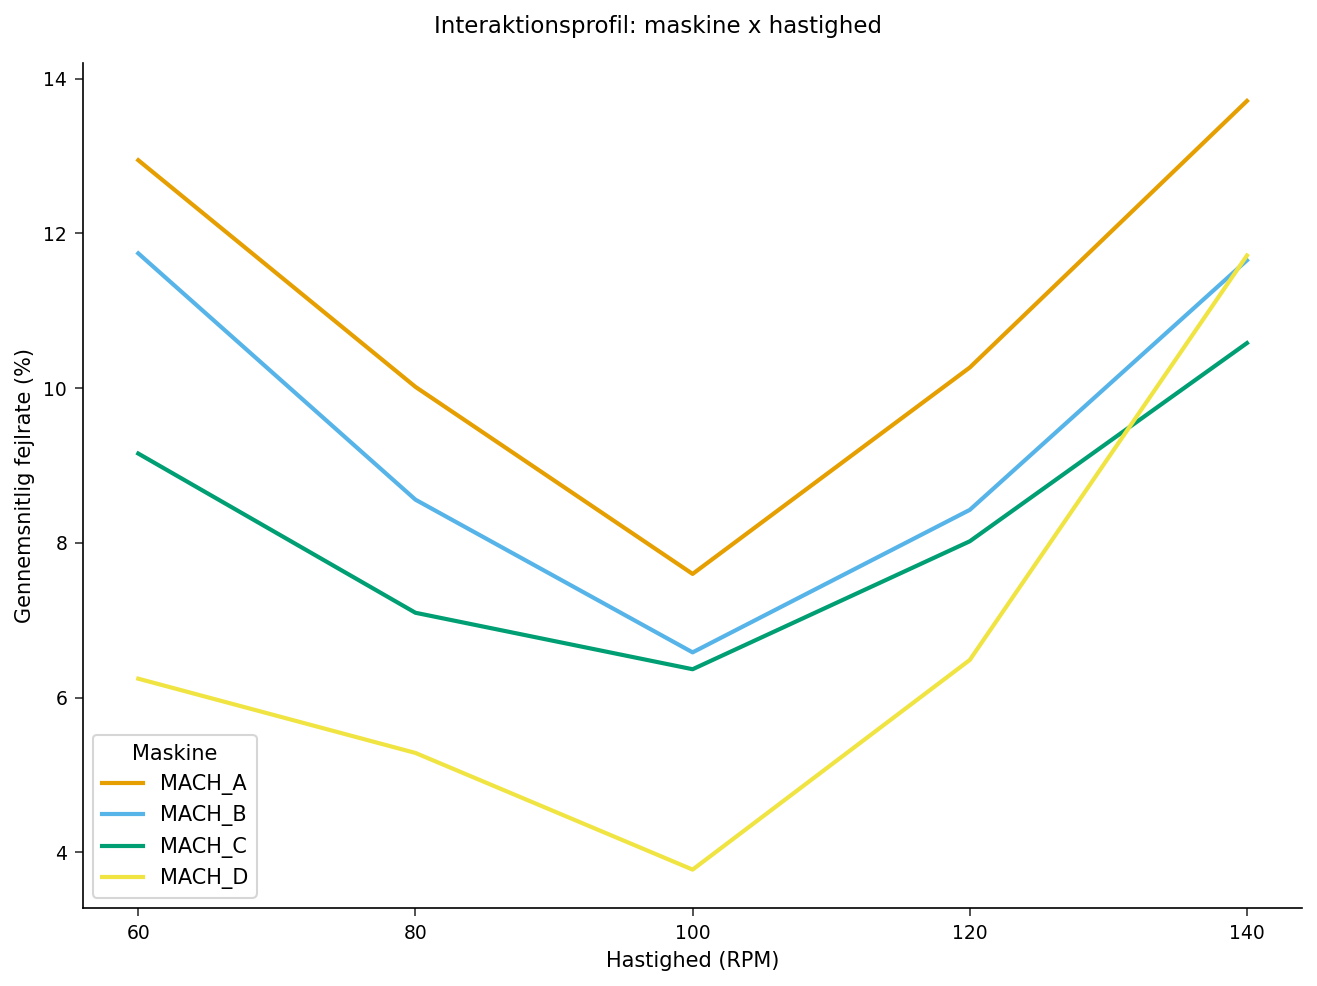

In [3]:
/* --------------------------------------------------------
   Interaktionsplot: gennemsnitlig fejlrate efter hastighed og maskine
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.molding_experiment NOPRINT;
    KLASSE machine speed;
    VARIABEL defect_rate;
    MÆRKAT machine='Maskine' speed='Hastighed (RPM)' defect_rate='Fejlrate (%)';
    UDDATA out=work.cell_means mean=mean_defect;
KØR;

PROCEDURE SGPLOT data=work.cell_means(HVOR=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS MÆRKAT='Hastighed (RPM)' VALUES=(60 80 100 120 140);
    YAXIS MÆRKAT='Gennemsnitlig fejlrate (%)';
    keylegend / TITEL='Maskine';
    TITEL 'Interaktionsprofil: maskine x hastighed';
KØR;

---

                                   Fejlrate og trækstyrke efter maskine og hastighed                                    

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable          Fejlrate (%)
Estimation Method                   REML
Degrees of Freedom Method  Kenward-Roger
Number of Observations               100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

         Type III Tests of Fixed Effects         

Effect       Num DF    Den DF   F Value    Pr > F
---------  --------  --------  --------  --------
Hastighed         4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514
AIC (Smaller is Better)  361.3513
BIC (Smaller is Better


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


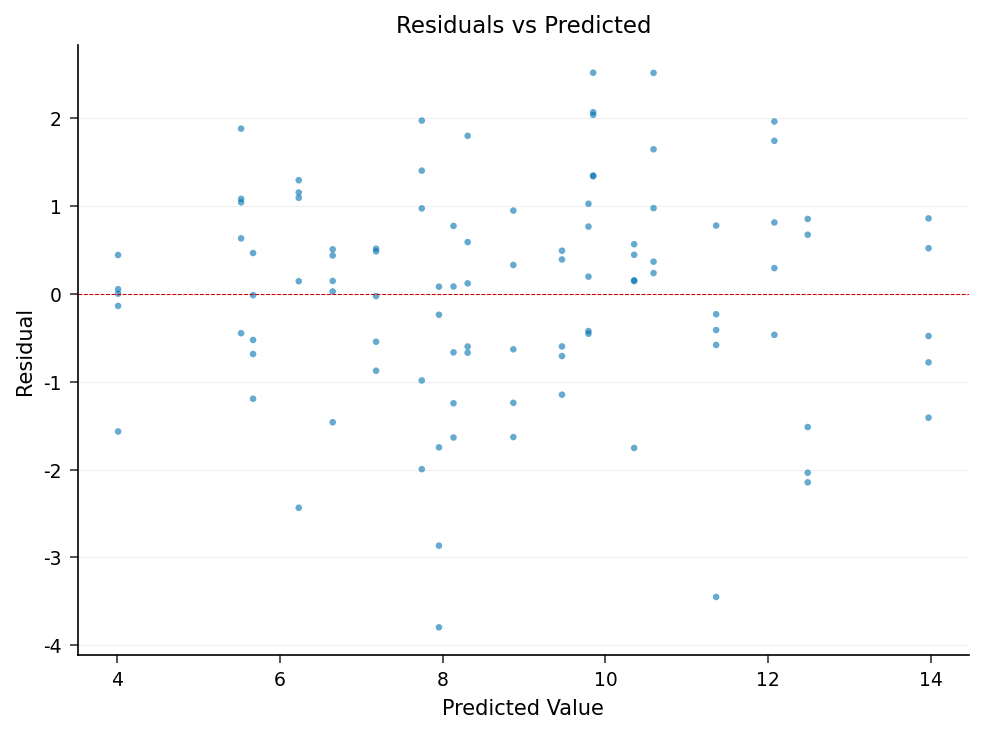

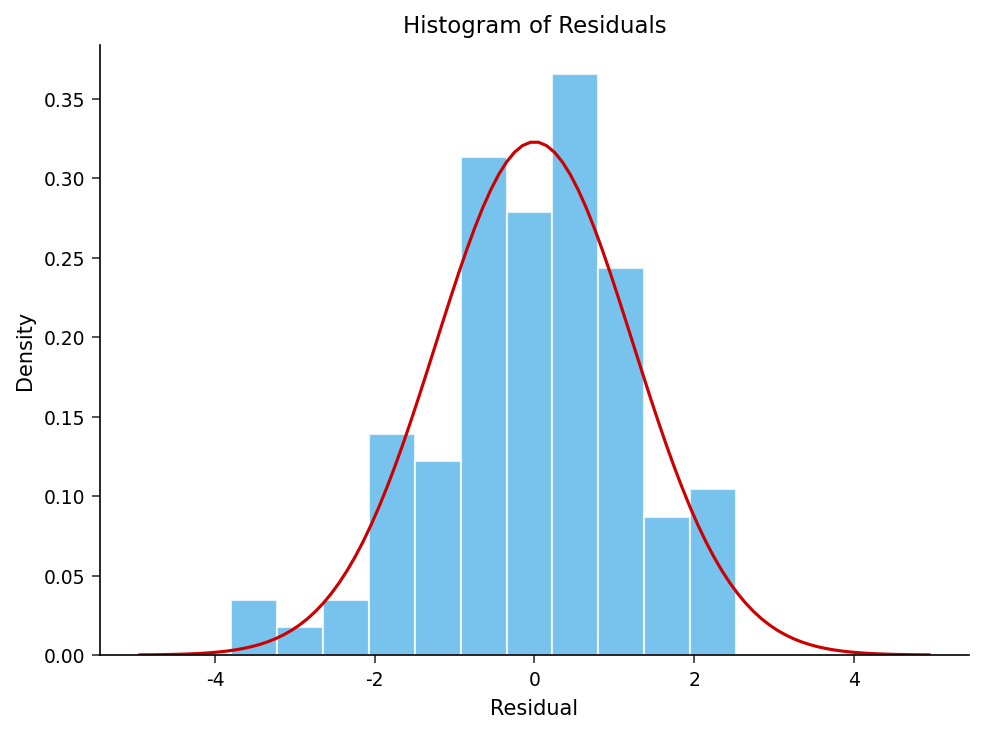

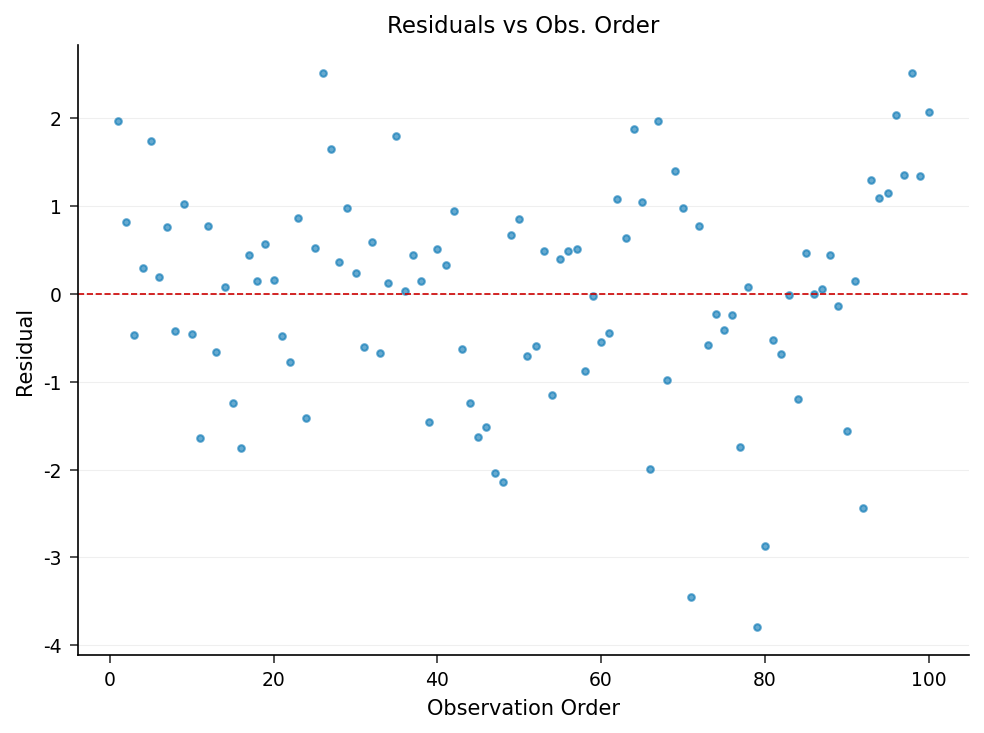

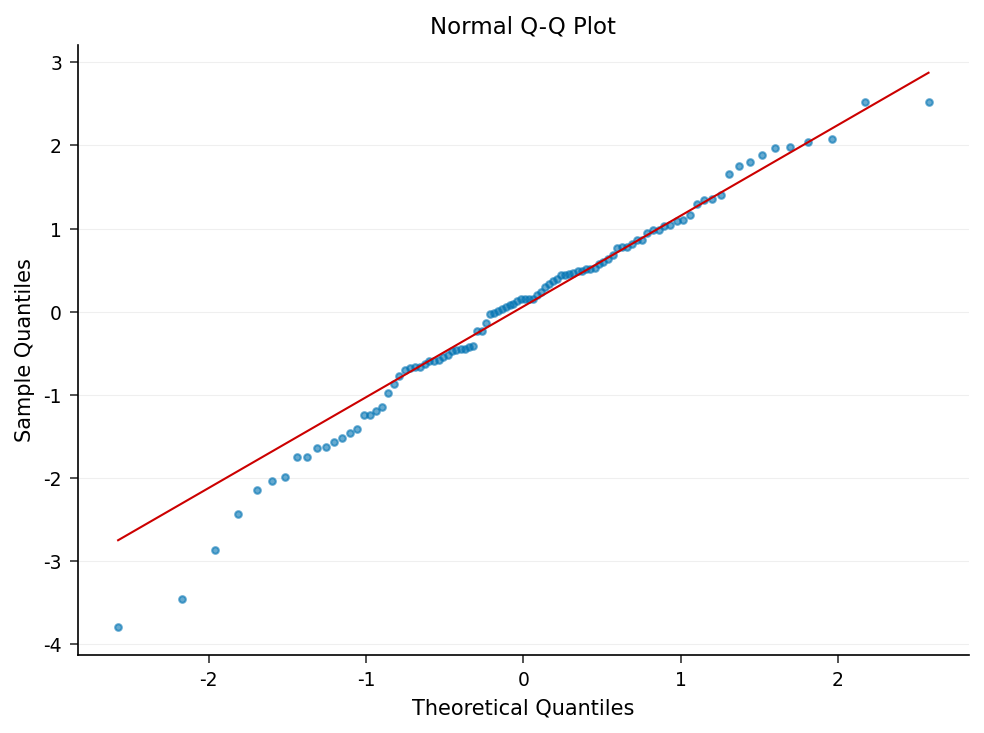

In [4]:
/* --------------------------------------------------------
   Split-plot mixed-model-analyse
   Maskine er tilfældig (hel-parcel-fejl)
   Hastighed er fixed (delparcel-faktor)
   -------------------------------------------------------- */
PROCEDURE MIXED data=work.molding_experiment METHOD=reml;
    KLASSE machine speed_label;
    MODEL defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    MÆRKAT defect_rate='Fejlrate (%)' machine='Maskine' speed_label='Hastighed';
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    TITEL 'Split-plot-analyse: hastighedens effekt på fejlrate';
KØR;

In [5]:
/* --------------------------------------------------------
   Identificér den optimale hastighedsindstilling
   -------------------------------------------------------- */
PROCEDURE SORTER data=work.speed_lsmeans;
    EFTER ESTIMATE;
KØR;

data work.optimal_speed;
    SÆT work.speed_lsmeans(obs=1);
    speed_label = treatment;
    BEHOLD speed_label ESTIMATE stderr LOWER UPPER;
    MÆRKAT speed_label = 'Optimal hastighed'
          ESTIMATE = 'LS-gennemsnit fejlrate'
          stderr = 'Standardfejl'
          LOWER = '95 % CI nedre grænse'
          UPPER = '95 % CI øvre grænse';
KØR;

PROCEDURE UDSKRIV data=work.optimal_speed noobs MÆRKAT;
    TITEL 'Anbefalet driftshastighed for minimal fejlrate';
KØR;

                                     Anbefalet driftshastighed for minimal fejlrate                                     

Optimal hastighed  LS-gennemsnit fejlrate  Standardfejl   95 % CI nedre grænse    95 % CI øvre grænse
100RPM                              6.081        0.9266                 3.3645                 8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Opdeling af variankomponenter
   -------------------------------------------------------- */
PROCEDURE UDSKRIV data=work.split_covparms noobs MÆRKAT;
    MÆRKAT CovParm='Kovariansparameter' Estimate='Estimat';
    TITEL 'Variankomponenter: maskine mod residual';
KØR;

                                        Variankomponenter: maskine mod residual                                         

Kovariansparameter  Estimat
Intercept            3.1033
Residual             1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Fortolkning

Split-plot-modellen opdeler variabiliteten i fejlraten i to lag.
**Maskine (hel-parcel) variankomponenten er 3,10**, og
**residualvariansen (delparcel) er 1,66**, så forskelle mellem
maskiner tegner sig for omkring **65 %** af den samlede varians
(3,10 / (3,10 + 1,66)). Denne store andel mellem maskiner bekræfter,
at maskine er en reel kilde til procesvariation, og at
split-plot-designet - frem for en fuldt randomiseret analyse - er den
korrekte ramme.

Type III-testen af den fixed hastighedseffekt er stærkt signifikant:
**F(4, 92) = 60,26, p < .0001**, så RPM-indstillingen påvirker
fejlraten markant. Least-squares-gennemsnittene tegner en tydelig
kvadratisk respons med et minimum ved den mellemste hastighed:

| Hastighed | LS-gennemsnit fejlrate (%) | 95 % CI |
|-------|------------------------|--------|
| **100 RPM** | **6,08** | 3,36 - 8,80 |
| 80 RPM | 7,74 | 5,02 - 10,46 |
| 120 RPM | 8,30 | 5,58 - 11,02 |
| 60 RPM | 10,02 | 7,31 - 12,74 |
| 140 RPM | 11,92 | 9,20 - 14,63 |

Tukey-justerede parvise sammenligninger viser, at **100 RPM er
signifikant lavere end alle andre indstillinger** (justeret p <= 0,0009
mod 80, 120, 60 og 140 RPM). Indstillingerne 80 RPM og 120 RPM ligger
i midten og adskiller sig **ikke** fra hinanden (forskel 0,56, justeret
p = 0,6430), mens 60 RPM og 140 RPM giver de højeste fejlrater.

**Anbefaling til produktionen:** standardisér produktionen ved
**100 RPM** på tværs af alle fire maskiner, hvor modellen estimerer
den laveste fejlrate (6,08 %). Fordi maskinens variankomponent (3,10)
er den dominerende kilde til variabilitet, bør opfølgningsarbejde
målrette maskinspecifik kalibrering - interaktionsprofilen viser, at
MACH_D konsekvent ligger lavest og MACH_A højest - for at lukke
forskellen mellem maskinerne ved det valgte sætpunkt på 100 RPM.

---

In [7]:
/* --------------------------------------------------------
   Eksportér hastighedsoptimeringsresultater til brug i produktionen
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>